
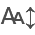

Reading adult.csv from ./data/
Dropped columns:['fnlwgt']

Raw NaN counts per column:
workclass         1836
occupation        1843
native.country     583
dtype: int64
Numeric: ['age', 'capital.gain', 'capital.loss', 'hours.per.week'] 
 Categorical: ['workclass', 'education', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country'], Continuous: ['age', 'capital.gain', 'capital.loss', 'hours.per.week']
Num_strat: mean, Cat_strat: most_frequent

Raw NaN counts per column:
Series([], dtype: int64)
Target_map: {'<=50K': 0, '>50K': 1}
Test_size: 0.3, Random_state: 42
Loaded classifier: random_forest for this month

WholeData class distribution:
       Count  Percentage
class                   
0      24720       75.92
1       7841       24.08

Train class distribution:
       Count  Percentage
class                   
<=50K  12112       75.92
>50K    3842       24.08

Test class distribution:
       Count  Percentage
class                   
<=50K   

### Average Metrics — Non-dominated Unique (Cov↑, Pre↑)

Loading ITables v2.4.4 from the init_notebook_mode cell... (need help?)


### Average Metrics —  Non-dominated Unique (Cov_class↑, Pre↑, Len↓)

Loading ITables v2.4.4 from the init_notebook_mode cell... (need help?)


### Pairwise Average Metrics Diffs — Non-dominated Unique(Cov↑, Pre↑)

Loading ITables v2.4.4 from the init_notebook_mode cell... (need help?)


### Pairwise Average Metrics Diffs — Non-dominated Unique(Cov_class↑, Pre↑, Len↓)

Loading ITables v2.4.4 from the init_notebook_mode cell... (need help?)


### Average Metrics Non-dominated (Cov↑, Pre↑), ideal rules — distance choice method

Loading ITables v2.4.4 from the init_notebook_mode cell... (need help?)


### Average Metrics Non-dominated (Cov↑, Pre↑), ideal rules — random choice method

Loading ITables v2.4.4 from the init_notebook_mode cell... (need help?)


### Average Metrics Non-dominated (Cov↑, Pre↑), ideal rules — sum choice method

Loading ITables v2.4.4 from the init_notebook_mode cell... (need help?)


### Average Metrics Non-dominated (Cov↑, Pre↑), ideal rules — product choice method

Loading ITables v2.4.4 from the init_notebook_mode cell... (need help?)


### Average Metrics Non-dominated (Cov_class↑, Pre↑, Len↓), ideal rules — distance choice method

Loading ITables v2.4.4 from the init_notebook_mode cell... (need help?)


### Average Metrics Non-dominated (Cov_class↑, Pre↑, Len↓), ideal rules — random choice method

Loading ITables v2.4.4 from the init_notebook_mode cell... (need help?)


### Average Metrics Non-dominated (Cov_class↑, Pre↑, Len↓), ideal rules — sum choice method

Loading ITables v2.4.4 from the init_notebook_mode cell... (need help?)


### Average Metrics Non-dominated (Cov_class↑, Pre↑, Len↓), ideal rules — product choice method

Loading ITables v2.4.4 from the init_notebook_mode cell... (need help?)


### Winner Matrix — Non-dominated (Cov↑, Pre↑)

Loading ITables v2.4.4 from the init_notebook_mode cell... (need help?)


### Winner Matrix — Non-dominated (Cov_class↑, Pre↑, Len↓)

Loading ITables v2.4.4 from the init_notebook_mode cell... (need help?)


### Average Rules per Step, Cat1 - (Cov↑, Pre↑), Cat2 - (Cov_class↑, Pre↑, Len↓)

Loading ITables v2.4.4 from the init_notebook_mode cell... (need help?)


### Average Number of Filtered Rules at Each Step, Cat1 - (Cov↑, Pre↑), Cat2 - (Cov_class↑, Pre↑, Len↓)

Loading ITables v2.4.4 from the init_notebook_mode cell... (need help?)


### Average Attribute Usage (Entropy)

Loading ITables v2.4.4 from the init_notebook_mode cell... (need help?)


### Average Jaccard Similarity (Pairs)

Loading ITables v2.4.4 from the init_notebook_mode cell... (need help?)


### Average Jaccard Similarity (Matrix)

Loading ITables v2.4.4 from the init_notebook_mode cell... (need help?)


### Attribute Usage — Non-Filtered (Avg per Instance)

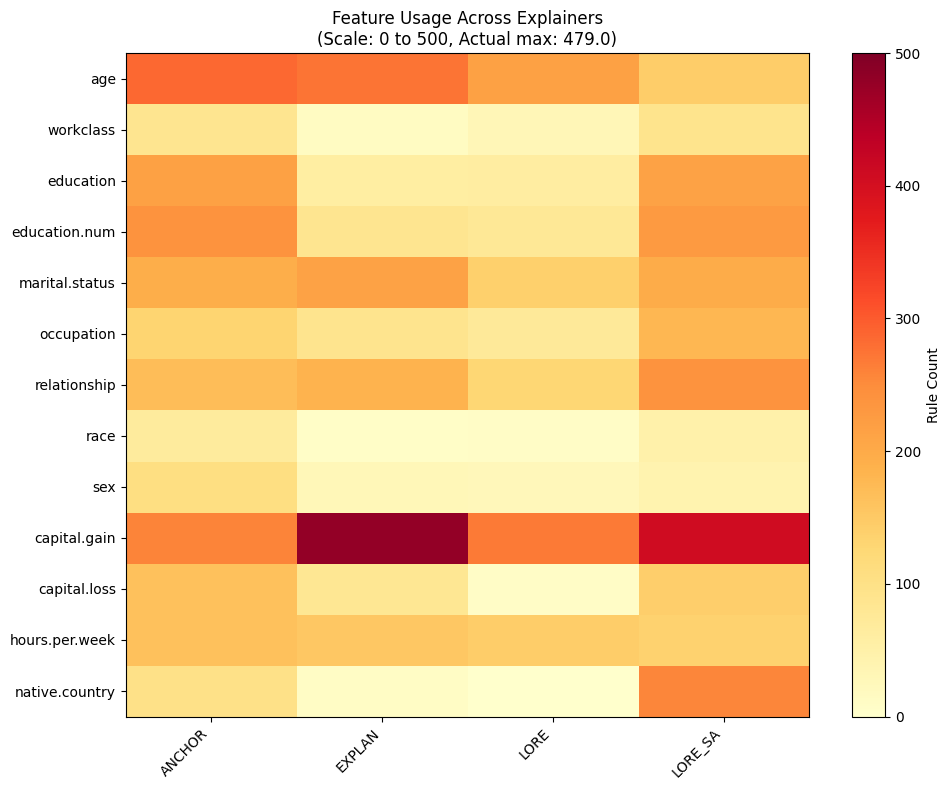

### Attribute Usage — Non-dominated Unique (Cov↑, Pre↑) (Avg per Instance)

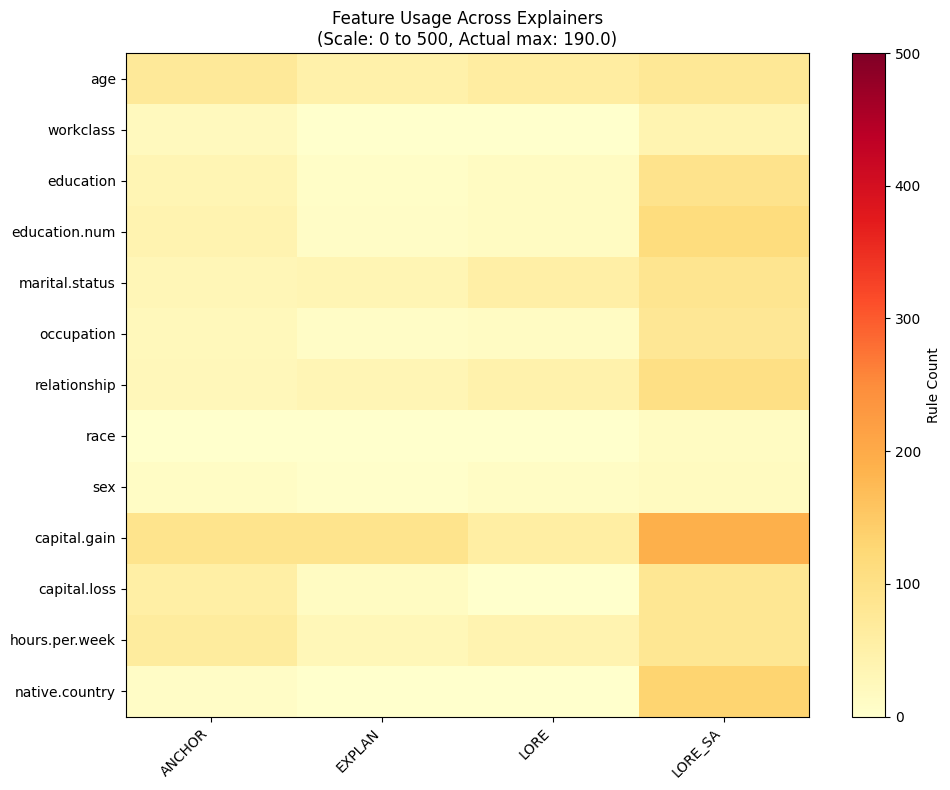

### Attribute Usage — Non-dominated Unique (Cov_class↑, Pre↑, Len↓) (Avg per Instance)

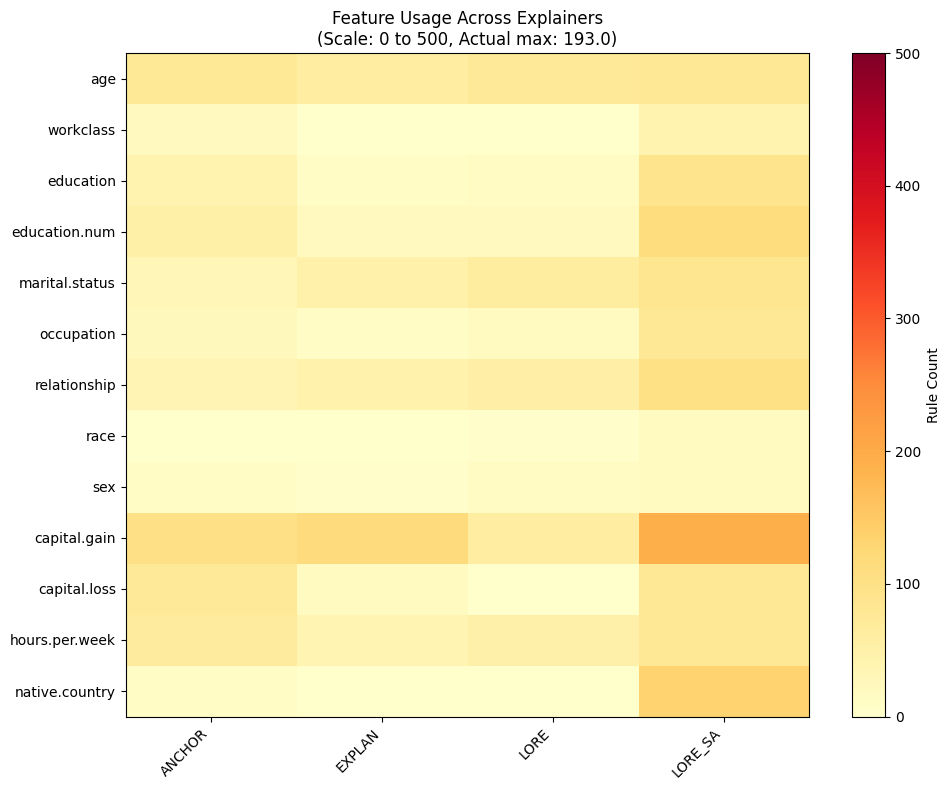

In [4]:
import os, sys
parent_dir = os.path.abspath(os.path.join(os.path.dirname("parser_main_general"), '..'))
sys.path.append(parent_dir)
from parser_main_general import analyze_results
from IPython.display import display, Markdown
from itables import init_notebook_mode, options, show
from parser_util import plot_feature_usage_heatmap, combine_winner_matrices
init_notebook_mode(all_interactive=True)
options.pageLength = 50

rules_log = "adult_random_forest_rules_07-21_21-08-2025.txt"
entries_log = "adult_random_forest_entries_07-21_21-08-2025.txt"
info_log = "adult_random_forest_info_07-21_21-08-2025.txt"
path="../../experiments_log/"
file_path = os.path.join(path, info_log)

with open(file_path, "r", encoding="utf-8") as f:
    content = f.read()

# Print the entire file content
print(content)

res = analyze_results(
    rules_log=rules_log,
    entries_log=entries_log,
    path=path,
    min_cov=0.01, min_cov_class=0.01, min_pre=0.01,
    random_seed=42,
    use_avg_attr_per_instance = False
)

combined_cat1 = combine_winner_matrices(
    res["winner_matrix_cat1_counts"],
    res["winner_matrix_cat1_ratio"]
)

combined_cat2 = combine_winner_matrices(
    res["winner_matrix_cat2_counts"],
    res["winner_matrix_cat2_ratio"]
)

# --- Classic summaries ---
display(Markdown("### Average Metrics — Non-dominated Unique (Cov↑, Pre↑)"))
show(res["summary_dom1"])

display(Markdown("### Average Metrics —  Non-dominated Unique (Cov_class↑, Pre↑, Len↓)"))
show(res["summary_dom2"])

# --- Pairwise diffs ---
display(Markdown("### Pairwise Average Metrics Diffs — Non-dominated Unique(Cov↑, Pre↑)"))
show(res["diff_dom1"])

display(Markdown("### Pairwise Average Metrics Diffs — Non-dominated Unique(Cov_class↑, Pre↑, Len↓)"))
show(res["diff_dom2"])

# --- Averaged metrics per explainer for each selection method ---
for m, df in res["choice_tables_cat1"].items():
    display(Markdown(f"### Average Metrics Non-dominated (Cov↑, Pre↑), ideal rules — {m} choice method"))
    show(df)

for m, df in res["choice_tables_cat2"].items():
    display(Markdown(f"### Average Metrics Non-dominated (Cov_class↑, Pre↑, Len↓), ideal rules — {m} choice method"))
    show(df)

# --- Winner matrices ---
display(Markdown("### Winner Matrix — Non-dominated (Cov↑, Pre↑)"))
show(combined_cat1)

display(Markdown("### Winner Matrix — Non-dominated (Cov_class↑, Pre↑, Len↓)"))
show(combined_cat2)

# --- Rules per step combined ---
display(Markdown("### Average Rules per Step, Cat1 - (Cov↑, Pre↑), Cat2 - (Cov_class↑, Pre↑, Len↓)"))
show(res["rules_per_step_combined"])

# --- Filtered per step combined ---
display(Markdown("### Average Number of Filtered Rules at Each Step, Cat1 - (Cov↑, Pre↑), Cat2 - (Cov_class↑, Pre↑, Len↓)"))
show(res["filtered_per_step_combined"])

# --- Attribute usage ---
display(Markdown("### Average Attribute Usage (Entropy)"))
show(res["attr_usage_avg"])

# --- Jaccard similarity ---
display(Markdown("### Average Jaccard Similarity (Pairs)"))
show(res["jaccard_pairs_avg"])

display(Markdown("### Average Jaccard Similarity (Matrix)"))
show(res["jaccard_matrix_avg"])

display(Markdown("### Attribute Usage — Non-Filtered (Avg per Instance)"))
plot_feature_usage_heatmap(
    res["attr_usage_original_tbl"], "Feature", "Explainer", "Count", all_features=res["attribute_universe"],vmax = 5*100
)
# Cat1 Unique
display(Markdown("### Attribute Usage — Non-dominated Unique (Cov↑, Pre↑) (Avg per Instance)"))
plot_feature_usage_heatmap(
    res["attr_usage_cat1_tbl"], "Feature", "Explainer", "Count", all_features=res["attribute_universe"],vmax = 5*100
)
# Cat2 Unique
display(Markdown("### Attribute Usage — Non-dominated Unique (Cov_class↑, Pre↑, Len↓) (Avg per Instance)"))
plot_feature_usage_heatmap(
    res["attr_usage_cat2_tbl"], "Feature", "Explainer", "Count", all_features=res["attribute_universe"],vmax = 5*100
)